In [38]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
import pandas as pd

# Define the file path
file_path = 'D:/DSGP project/DSGP/datasets/raw/Crop_and_fertilizer_dataset.csv'

# Load the dataset
data = pd.read_csv(file_path)

# Display dataset information
print("First few rows of the dataset:")
print(data.head())

print("\nDataset information:")
print(data.info())


First few rows of the dataset:
  District_Name Soil_color  Nitrogen  Phosphorus  Potassium   pH  Rainfall  \
0      Kolhapur      Black        75          50        100  6.5      1000   
1      Kolhapur      Black        80          50        100  6.5      1000   
2      Kolhapur      Black        85          50        100  6.5      1000   
3      Kolhapur      Black        90          50        100  6.5      1000   
4      Kolhapur      Black        95          50        100  6.5      1000   

   Temperature       Crop Fertilizer                          Link  
0           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  
1           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  
2           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  
3           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  
4           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4513 entries, 

In [40]:
# Check the columns and data types
print(data.info())

# Check for null values
print(data.isnull().sum())

# Summary statistics for numerical columns
print(data.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4513 entries, 0 to 4512
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   District_Name  4513 non-null   object 
 1   Soil_color     4513 non-null   object 
 2   Nitrogen       4513 non-null   int64  
 3   Phosphorus     4513 non-null   int64  
 4   Potassium      4513 non-null   int64  
 5   pH             4513 non-null   float64
 6   Rainfall       4513 non-null   int64  
 7   Temperature    4513 non-null   int64  
 8   Crop           4513 non-null   object 
 9   Fertilizer     4513 non-null   object 
 10  Link           4513 non-null   object 
dtypes: float64(1), int64(5), object(5)
memory usage: 388.0+ KB
None
District_Name    0
Soil_color       0
Nitrogen         0
Phosphorus       0
Potassium        0
pH               0
Rainfall         0
Temperature      0
Crop             0
Fertilizer       0
Link             0
dtype: int64
          Nitrogen   Phosphoru

In [41]:
# Keep only relevant columns
relevant_columns = ['Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature']
filtered_data = data[relevant_columns]
print(filtered_data.head())

   Nitrogen  Phosphorus  Potassium   pH  Rainfall  Temperature
0        75          50        100  6.5      1000           20
1        80          50        100  6.5      1000           20
2        85          50        100  6.5      1000           20
3        90          50        100  6.5      1000           20
4        95          50        100  6.5      1000           20


In [42]:
# Handle missing values

# Handle missing values (NaN) using imputation
# Fill with the mean (suitable for numerical data)
for col in ['Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature']:
    filtered_data[col] = filtered_data[col].fillna(filtered_data[col].mean())

# Fill with a specific value (e.g., 0)
filtered_data.fillna(0, inplace=True)

# Drop rows with missing values (if the number of missing values is small)
filtered_data.dropna(inplace=True)


# Verify if there are still missing values after handling
print(filtered_data.isnull().sum())

print(filtered_data.head())

Nitrogen       0
Phosphorus     0
Potassium      0
pH             0
Rainfall       0
Temperature    0
dtype: int64
   Nitrogen  Phosphorus  Potassium   pH  Rainfall  Temperature
0        75          50        100  6.5      1000           20
1        80          50        100  6.5      1000           20
2        85          50        100  6.5      1000           20
3        90          50        100  6.5      1000           20
4        95          50        100  6.5      1000           20


C:\Users\dinit\AppData\Local\Temp\ipykernel_2632\3062463761.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data[col] = filtered_data[col].fillna(filtered_data[col].mean())
C:\Users\dinit\AppData\Local\Temp\ipykernel_2632\3062463761.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.fillna(0, inplace=True)
C:\Users\dinit\AppData\Local\Temp\ipykernel_2632\3062463761.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

In [43]:
# Remove duplicate rows based on all columns
filtered_data = filtered_data.drop_duplicates()

# Display the DataFrame after removing duplicates
print(filtered_data.head())
filtered_data.shape

   Nitrogen  Phosphorus  Potassium   pH  Rainfall  Temperature
0        75          50        100  6.5      1000           20
1        80          50        100  6.5      1000           20
2        85          50        100  6.5      1000           20
3        90          50        100  6.5      1000           20
4        95          50        100  6.5      1000           20


(4436, 6)

In [44]:
# Handle Outliers using IQR

import pandas as pd

# Assuming 'filtered_data' DataFrame from the previous code

def handle_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_filtered

# Apply the function to each relevant column
for col in ['Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature']:
    filtered_data = handle_outliers_iqr(filtered_data, col)

print(filtered_data.shape)
print(filtered_data.head())

(3797, 6)
   Nitrogen  Phosphorus  Potassium   pH  Rainfall  Temperature
0        75          50        100  6.5      1000           20
1        80          50        100  6.5      1000           20
2        85          50        100  6.5      1000           20
3        90          50        100  6.5      1000           20
4        95          50        100  6.5      1000           20


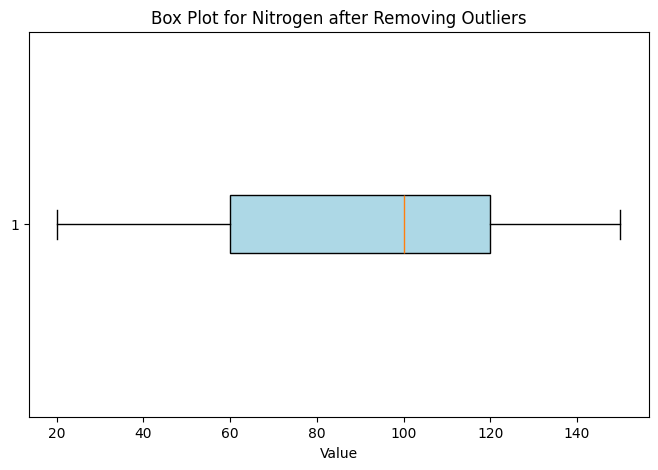

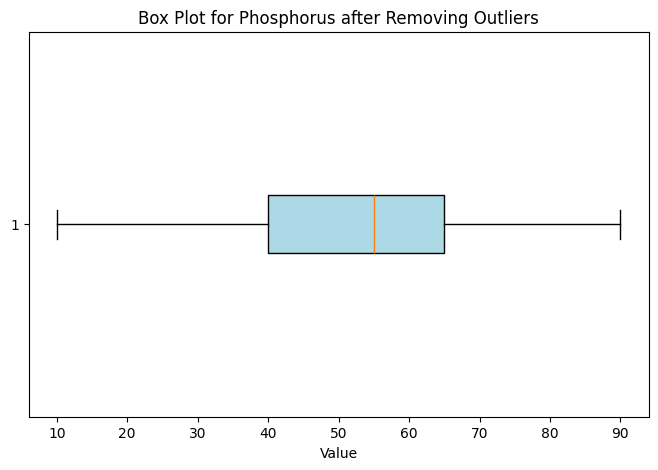

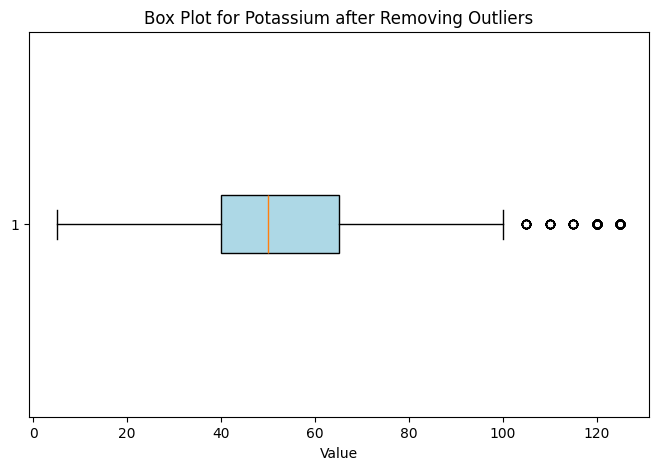

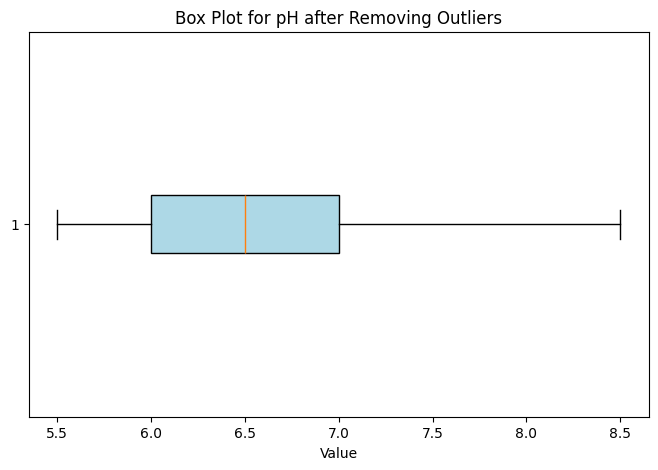

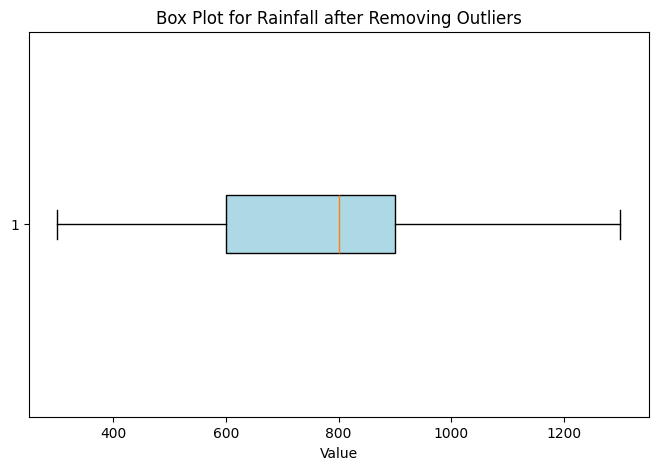

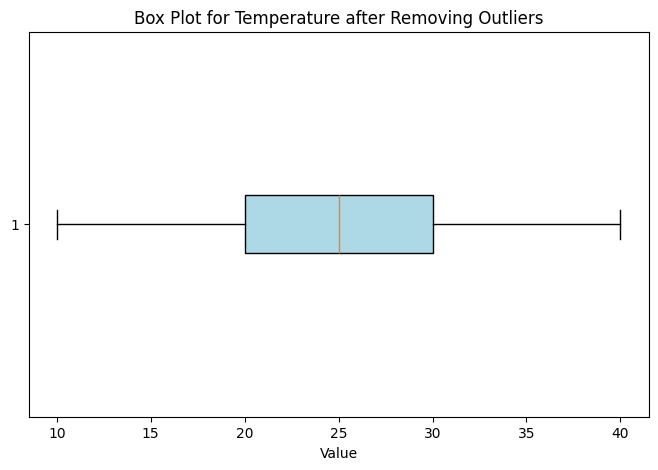

In [45]:
import matplotlib.pyplot as plt

# List of columns to visualize with boxplots
columns_to_visualize = ['Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature']

# Iterate through each column, plot a boxplot after outlier removal
for column in columns_to_visualize:
    plt.figure(figsize=(8, 5)) 
    plt.boxplot(
        filtered_data[column], 
        vert=False,  
        patch_artist=True,  # Color the box
        boxprops=dict(facecolor="lightblue") 
    )
    
    # Add title and labels
    plt.title(f"Box Plot for {column} after Removing Outliers")  
    plt.xlabel("Value")  
    
    plt.show()

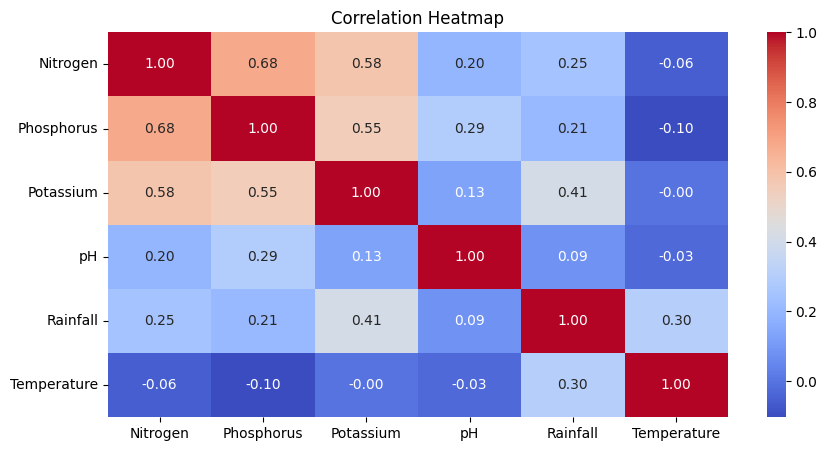

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = filtered_data.corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [47]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
# Normalize Numerical Features
from sklearn.preprocessing import MinMaxScaler

# Create a MinMaxScaler object
scaler = MinMaxScaler()

# Select numerical features to scale
numerical_features = ['Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature']

# Fit and transform the numerical features
filtered_data[numerical_features] = scaler.fit_transform(filtered_data[numerical_features])

# Display the first few rows of the scaled data
print(filtered_data.head())

   Nitrogen  Phosphorus  Potassium        pH  Rainfall  Temperature
0  0.423077         0.5   0.791667  0.333333       0.7     0.333333
1  0.461538         0.5   0.791667  0.333333       0.7     0.333333
2  0.500000         0.5   0.791667  0.333333       0.7     0.333333
3  0.538462         0.5   0.791667  0.333333       0.7     0.333333
4  0.576923         0.5   0.791667  0.333333       0.7     0.333333


In [49]:
# Split data into inputs (X) and outputs (y)
# Inputs: Environmental and soil conditions
X = filtered_data[['pH', 'Rainfall', 'Temperature', 'Nitrogen', 'Phosphorus', 'Potassium']]

# Outputs: Target fertilizer recommendations (amount of NPK to be added)
y = filtered_data[['Nitrogen', 'Phosphorus', 'Potassium']]


In [50]:
# Apply Random Forest Regressor to compute feature importance

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)  # You can adjust n_estimators
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Get feature importances
feature_importances = rf_model.feature_importances_

# Print feature importances
for i, feature_name in enumerate(X.columns):
    print(f"Feature Importance of {feature_name}: {feature_importances[i]}")

Feature Importance of pH: 0.0009475121034771707
Feature Importance of Rainfall: 0.0007609533291264815
Feature Importance of Temperature: 0.0007003225484683871
Feature Importance of Nitrogen: 0.6506901784525138
Feature Importance of Phosphorus: 0.12021771062322784
Feature Importance of Potassium: 0.22668332294318636


In [51]:
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


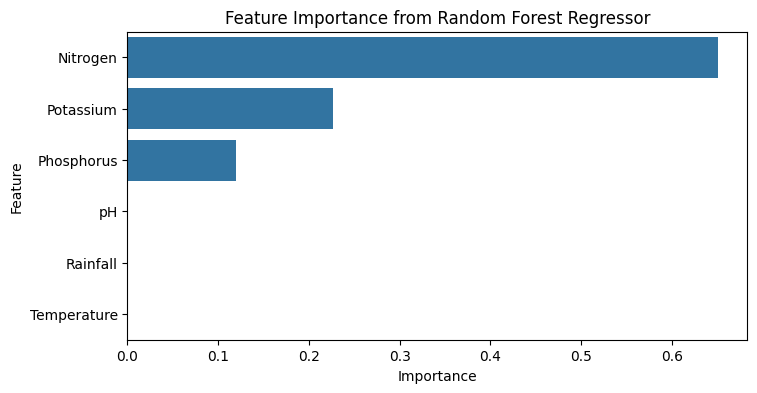

In [52]:
# Visualize feature importance

import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Create a bar plot of feature importances
plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance from Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [53]:
# Dimensionality Reduction with PCA

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA to reduce features while maintaining 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Number of components selected by PCA: {pca.n_components_}")


Number of components selected by PCA: 6


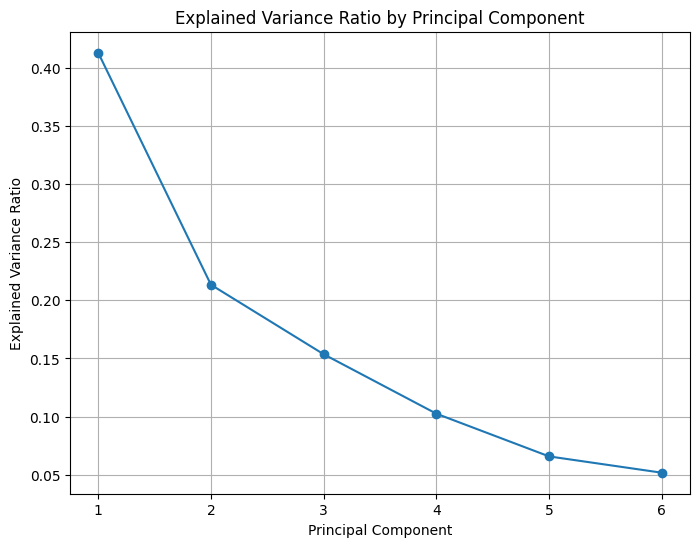

In [54]:

# Visualize explained variance ratio
plt.figure(figsize=(8, 6))
plt.plot(range(1, pca.n_components_ + 1), pca.explained_variance_ratio_, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio by Principal Component')
plt.grid(True)
plt.show()

In [55]:
# Decision Tree Feature Selection
from sklearn.tree import DecisionTreeRegressor

# Create and fit the Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

# Feature importance from Decision Tree
dt_feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Decision Tree Feature Importances:\n", dt_feature_importances)

Decision Tree Feature Importances:
        Feature  Importance
3     Nitrogen    0.656057
5    Potassium    0.222942
4   Phosphorus    0.119242
0           pH    0.000811
2  Temperature    0.000681
1     Rainfall    0.000266


In [56]:
# Regression Feature Contribution
from sklearn.linear_model import LinearRegression

# Create and fit the Linear Regression model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Coefficients from Regression
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("Regression Coefficients:\n", coefficients)

Regression Coefficients:
        Feature   Coefficient
3     Nitrogen  1.000000e+00
5    Potassium  1.920093e-17
4   Phosphorus -1.053439e-16
2  Temperature -2.002452e-16
1     Rainfall -2.220446e-16
0           pH -6.437825e-16


In [57]:
# Combine Results to Finalize Features

# Combine Feature Importance Scores
# Create a dictionary to store feature importance from different methods
feature_importance_dict = {}

# Add Random Forest feature importance
for i, feature_name in enumerate(X.columns):
    feature_importance_dict[feature_name] = feature_importance_dict.get(feature_name, 0) + feature_importances[i]

# Add Decision Tree feature importance
for index, row in dt_feature_importances.iterrows():
    feature_importance_dict[row['Feature']] = feature_importance_dict.get(row['Feature'], 0) + row['Importance']

# Add Linear Regression coefficients (magnitude as importance)
for index, row in coefficients.iterrows():
    feature_importance_dict[row['Feature']] = feature_importance_dict.get(row['Feature'], 0) + abs(row['Coefficient'])

# Convert the dictionary to a DataFrame
combined_importance_df = pd.DataFrame.from_dict(feature_importance_dict, orient='index', columns=['Combined Importance'])

# Sort by combined importance
combined_importance_df = combined_importance_df.sort_values(by='Combined Importance', ascending=False)

# Display the combined feature importance
print("\nCombined Feature Importance:\n", combined_importance_df)

# Final Feature Selection: Select all 6 features (no filtering based on importance)
selected_features = ['Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature']

print("\nSelected Features:", selected_features)

# Prepare the dataset with selected features
X_selected = X[selected_features]
X_train_selected, X_test_selected, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Train the Random Forest Regressor with all 6 selected features
rf_model_selected = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_selected.fit(X_train_selected, y_train)
y_pred_selected = rf_model_selected.predict(X_test_selected)

# Evaluate the model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse_selected = mean_squared_error(y_test, y_pred_selected)
mae_selected = mean_absolute_error(y_test, y_pred_selected)
r2_selected = r2_score(y_test, y_pred_selected)

print(f"Model Evaluation with Selected Features:")
print(f"Mean Squared Error: {mse_selected:.4f}")
print(f"Mean Absolute Error: {mae_selected:.4f}")
print(f"R2 Score: {r2_selected:.4f}")


Combined Feature Importance:
              Combined Importance
Nitrogen                2.306747
Potassium               0.449625
Phosphorus              0.239460
pH                      0.001758
Temperature             0.001382
Rainfall                0.001027

Selected Features: ['Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature']
Model Evaluation with Selected Features:
Mean Squared Error: 0.0001
Mean Absolute Error: 0.0062
R2 Score: 0.9980


In [59]:
# Save the final dataset (filtered_data) to folder
final_dataset_path = 'D:/DSGP project/DSGP/datasets/processed/Final_Fertilizer_Dataset.csv'
filtered_data.to_csv(final_dataset_path, index=False)

In [60]:
# Load the final dataset
import pandas as pd
final_file_path = 'D:/DSGP project/DSGP/datasets/processed/Final_Fertilizer_Dataset.csv'
final_data = pd.read_csv(final_file_path)
print(final_data.head())

   Nitrogen  Phosphorus  Potassium        pH  Rainfall  Temperature
0  0.423077         0.5   0.791667  0.333333       0.7     0.333333
1  0.461538         0.5   0.791667  0.333333       0.7     0.333333
2  0.500000         0.5   0.791667  0.333333       0.7     0.333333
3  0.538462         0.5   0.791667  0.333333       0.7     0.333333
4  0.576923         0.5   0.791667  0.333333       0.7     0.333333


In [61]:
# Train the model with Random Forest Regressor
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


# Define features and targets
X = data.drop(['Nitrogen', 'Phosphorus', 'Potassium', 'District_Name'], axis=1)  # Drop 'District_Name'

# Convert columns with string values to numerical using one-hot encoding
X = pd.get_dummies(X)  # This will convert categorical columns into numerical

y = data[['Nitrogen', 'Phosphorus', 'Potassium']]

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
r2 = r2_score(y_test, y_pred, multioutput='variance_weighted')

# Display the results
print("Random Forest Regressor Results:")
print(f"Mean Squared Error (MSE):")
print(f"  - Nitrogen: {mse[0]:.2f}")
print(f"  - Phosphorus: {mse[1]:.2f}")
print(f"  - Potassium: {mse[2]:.2f}")
print(f"R^2 Score: {r2:.2f}")


Random Forest Regressor Results:
Mean Squared Error (MSE):
  - Nitrogen: 152.10
  - Phosphorus: 42.71
  - Potassium: 38.02
R^2 Score: 0.92


In [62]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: xgboost in c:\users\dinit\appdata\local\programs\python\python312\lib\site-packages (2.1.3)




[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [63]:
# Train the model XGBoost Regressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the XGBoost Regressor
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Predict on the test set
y_pred = xgb_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
r2 = r2_score(y_test, y_pred, multioutput='variance_weighted')

# Display the results
print("Gradient Boosting Regressor (XGBoost) Results:")
print(f"Mean Squared Error (MSE):")
print(f"  - Nitrogen: {mse[0]:.2f}")
print(f"  - Phosphorus: {mse[1]:.2f}")
print(f"  - Potassium: {mse[2]:.2f}")
print(f"R^2 Score: {r2:.2f}")


Gradient Boosting Regressor (XGBoost) Results:
Mean Squared Error (MSE):
  - Nitrogen: 150.16
  - Phosphorus: 57.23
  - Potassium: 71.79
R^2 Score: 0.91


In [64]:
# Train the model with SVR
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Scale the features for SVR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the SVR model (for one target variable at a time)
svr_model_N = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_model_P = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_model_K = SVR(kernel='rbf', C=1.0, epsilon=0.1)

# Train the models for each target variable
svr_model_N.fit(X_train_scaled, y_train['Nitrogen'])
svr_model_P.fit(X_train_scaled, y_train['Phosphorus'])
svr_model_K.fit(X_train_scaled, y_train['Potassium'])

# Predict for each target variable
y_pred_N = svr_model_N.predict(X_test_scaled)
y_pred_P = svr_model_P.predict(X_test_scaled)
y_pred_K = svr_model_K.predict(X_test_scaled)

# Combine predictions
y_pred = pd.DataFrame({
    'Nitrogen': y_pred_N,
    'Phosphorus': y_pred_P,
    'Potassium': y_pred_K
}, index=X_test.index)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
r2 = r2_score(y_test, y_pred, multioutput='variance_weighted')

# Display the results
print("Support Vector Regressor (SVR) Results:")
print(f"Mean Squared Error (MSE):")
print(f"  - Nitrogen: {mse[0]:.2f}")
print(f"  - Phosphorus: {mse[1]:.2f}")
print(f"  - Potassium: {mse[2]:.2f}")
print(f"R^2 Score: {r2:.2f}")


Support Vector Regressor (SVR) Results:
Mean Squared Error (MSE):
  - Nitrogen: 582.66
  - Phosphorus: 139.85
  - Potassium: 372.24
R^2 Score: 0.63


In [65]:
# Train the model with MLP
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Scale the features for MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the MLP Regressor
mlp_model = MLPRegressor(hidden_layer_sizes=(100, 50),  # Two hidden layers
                         activation='relu',            # Activation function
                         solver='adam',                # Optimization algorithm
                         learning_rate='adaptive',     # Dynamic learning rate
                         max_iter=500,                 # Maximum iterations
                         random_state=42)

# Train the model
mlp_model.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = mlp_model.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
r2 = r2_score(y_test, y_pred, multioutput='variance_weighted')

# Display the results
print("Multi-Layer Perceptron (MLP) Results:")
print(f"Mean Squared Error (MSE):")
print(f"  - Nitrogen: {mse[0]:.2f}")
print(f"  - Phosphorus: {mse[1]:.2f}")
print(f"  - Potassium: {mse[2]:.2f}")
print(f"R^2 Score: {r2:.2f}")


Multi-Layer Perceptron (MLP) Results:
Mean Squared Error (MSE):
  - Nitrogen: 224.70
  - Phosphorus: 82.87
  - Potassium: 114.26
R^2 Score: 0.86


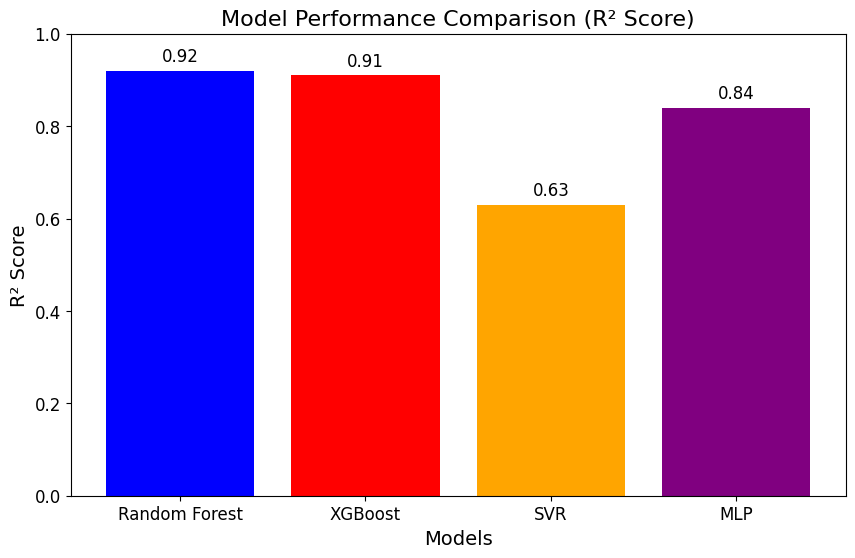

In [66]:
# Visualize R² scores for better comparison
import matplotlib.pyplot as plt
import numpy as np

# Model names and R² scores
models = ['Random Forest', 'XGBoost', 'SVR', 'MLP']
r2_scores = [0.92, 0.91, 0.63, 0.84]

# Bar chart
plt.figure(figsize=(10, 6))
plt.bar(models, r2_scores, color=['blue', 'red', 'orange', 'purple'])
plt.ylim(0, 1)  # Set y-axis limits to 0-1 for R² scores
plt.title('Model Performance Comparison (R² Score)', fontsize=16)
plt.xlabel('Models', fontsize=14)
plt.ylabel('R² Score', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Annotate scores on bars
for i, score in enumerate(r2_scores):
    plt.text(i, score + 0.02, f"{score:.2f}", ha='center', fontsize=12)

plt.show()



In [67]:
%pip install joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [68]:
# Hyperparameter Tuning with XGBoost
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Define features and targets
X = data.drop(['Nitrogen', 'Phosphorus', 'Potassium'], axis=1)
y = data[['Nitrogen', 'Phosphorus', 'Potassium']]

# Convert columns with string values to numerical using one-hot encoding
X = pd.get_dummies(X)  # Convert categorical columns to numerical

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the XGBoost model with tuned hyperparameters and eval_metric
xgb_model = XGBRegressor(
    colsample_bytree=1.0,
    learning_rate=0.2,
    max_depth=7,
    n_estimators=300,
    subsample=1.0,
    random_state=42,
    eval_metric="rmse" # Specify eval_metric here
)

# Train the model
# Removed eval_set, eval_metric, and early_stopping_rounds from fit
xgb_model.fit(
    X_train,
    y_train,
    verbose=True
)

# Predict on the test set
y_pred = xgb_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
r2 = r2_score(y_test, y_pred, multioutput='variance_weighted')

# Display the results
print("XGBoost with Tuned Hyperparameters Results:")
print(f"Mean Squared Error (MSE):")
print(f"  - Nitrogen: {mse[0]:.2f}")
print(f"  - Phosphorus: {mse[1]:.2f}")
print(f"  - Potassium: {mse[2]:.2f}")
print(f"R^2 Score: {r2:.2f}")

XGBoost with Tuned Hyperparameters Results:
Mean Squared Error (MSE):
  - Nitrogen: 117.18
  - Phosphorus: 41.15
  - Potassium: 15.38
R^2 Score: 0.94


In [69]:
from sklearn.metrics import mean_squared_error, r2_score

# Predict on training and test sets
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

# Calculate metrics for training set
train_mse = mean_squared_error(y_train, y_train_pred, multioutput='raw_values')
train_r2 = r2_score(y_train, y_train_pred, multioutput='variance_weighted')

# Calculate metrics for test set
test_mse = mean_squared_error(y_test, y_test_pred, multioutput='raw_values')
test_r2 = r2_score(y_test, y_test_pred, multioutput='variance_weighted')

# Display the results
print("Training Set Results:")
print(f"Mean Squared Error (MSE):")
print(f"  - Nitrogen: {train_mse[0]:.2f}")
print(f"  - Phosphorus: {train_mse[1]:.2f}")
print(f"  - Potassium: {train_mse[2]:.2f}")
print(f"R^2 Score: {train_r2:.2f}")

print("\nTest Set Results:")
print(f"Mean Squared Error (MSE):")
print(f"  - Nitrogen: {test_mse[0]:.2f}")
print(f"  - Phosphorus: {test_mse[1]:.2f}")
print(f"  - Potassium: {test_mse[2]:.2f}")
print(f"R^2 Score: {test_r2:.2f}")


Training Set Results:
Mean Squared Error (MSE):
  - Nitrogen: 96.70
  - Phosphorus: 31.14
  - Potassium: 12.51
R^2 Score: 0.95

Test Set Results:
Mean Squared Error (MSE):
  - Nitrogen: 117.18
  - Phosphorus: 41.15
  - Potassium: 15.38
R^2 Score: 0.94


[0]	validation_0-rmse:29.61216	validation_1-rmse:29.50159
[1]	validation_0-rmse:24.41155	validation_1-rmse:24.29361
[2]	validation_0-rmse:20.35571	validation_1-rmse:20.24396
[3]	validation_0-rmse:17.24797	validation_1-rmse:17.16413
[4]	validation_0-rmse:14.90342	validation_1-rmse:14.85173
[5]	validation_0-rmse:13.09393	validation_1-rmse:13.05831
[6]	validation_0-rmse:11.79335	validation_1-rmse:11.77082
[7]	validation_0-rmse:10.78217	validation_1-rmse:10.79849
[8]	validation_0-rmse:10.09540	validation_1-rmse:10.15609
[9]	validation_0-rmse:9.53904	validation_1-rmse:9.65650
[10]	validation_0-rmse:9.16452	validation_1-rmse:9.32759
[11]	validation_0-rmse:8.89957	validation_1-rmse:9.10427
[12]	validation_0-rmse:8.68097	validation_1-rmse:8.91891
[13]	validation_0-rmse:8.47529	validation_1-rmse:8.74860
[14]	validation_0-rmse:8.30314	validation_1-rmse:8.62196
[15]	validation_0-rmse:8.20868	validation_1-rmse:8.55830
[16]	validation_0-rmse:8.07334	validation_1-rmse:8.46396
[17]	validation_0-rmse:

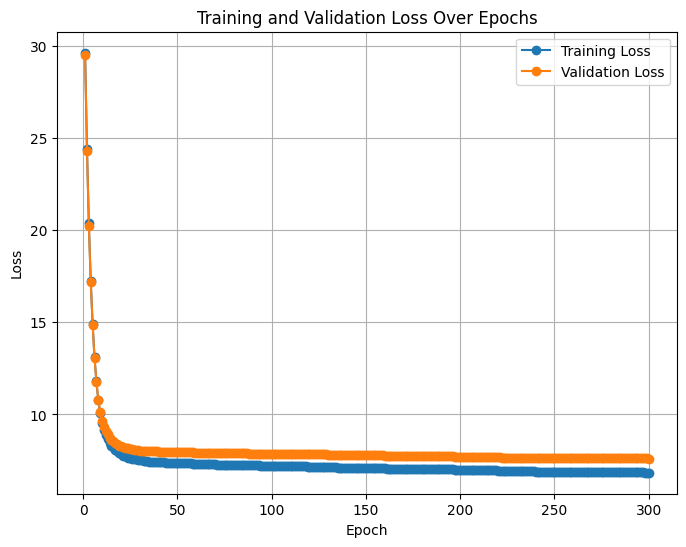

In [70]:
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Define features and targets
X = data.drop(['Nitrogen', 'Phosphorus', 'Potassium'], axis=1)
y = data[['Nitrogen', 'Phosphorus', 'Potassium']]

# Convert columns with string values to numerical using one-hot encoding
X = pd.get_dummies(X)  # Convert categorical columns to numerical

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the XGBoost model with evaluation metrics
xgb_model = XGBRegressor(
    colsample_bytree=1.0,
    learning_rate=0.2,
    max_depth=7,
    n_estimators=300,
    subsample=1.0,
    random_state=42,
    eval_metric="rmse"
)

# Train the model with evaluation sets
eval_set = [(X_train, y_train), (X_val, y_val)]
xgb_model.fit(X_train, y_train, eval_set=eval_set, verbose=True)

# Access evaluation results
results = xgb_model.evals_result()

# Extract training and validation loss
train_loss = results['validation_0']['rmse']
val_loss = results['validation_1']['rmse']
epochs = range(1, len(train_loss) + 1)

# Plot training and validation loss
plt.figure(figsize=(8, 6))
plt.plot(epochs, train_loss, label="Training Loss", marker='o')
plt.plot(epochs, val_loss, label="Validation Loss", marker='o')
plt.title("Training and Validation Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()


[0]	validation_0-rmse:29.61216	validation_1-rmse:29.50159
[1]	validation_0-rmse:24.41155	validation_1-rmse:24.29361
[2]	validation_0-rmse:20.35571	validation_1-rmse:20.24396
[3]	validation_0-rmse:17.24797	validation_1-rmse:17.16413
[4]	validation_0-rmse:14.90342	validation_1-rmse:14.85173
[5]	validation_0-rmse:13.09393	validation_1-rmse:13.05831
[6]	validation_0-rmse:11.79335	validation_1-rmse:11.77082
[7]	validation_0-rmse:10.78217	validation_1-rmse:10.79849
[8]	validation_0-rmse:10.09540	validation_1-rmse:10.15609
[9]	validation_0-rmse:9.53904	validation_1-rmse:9.65650


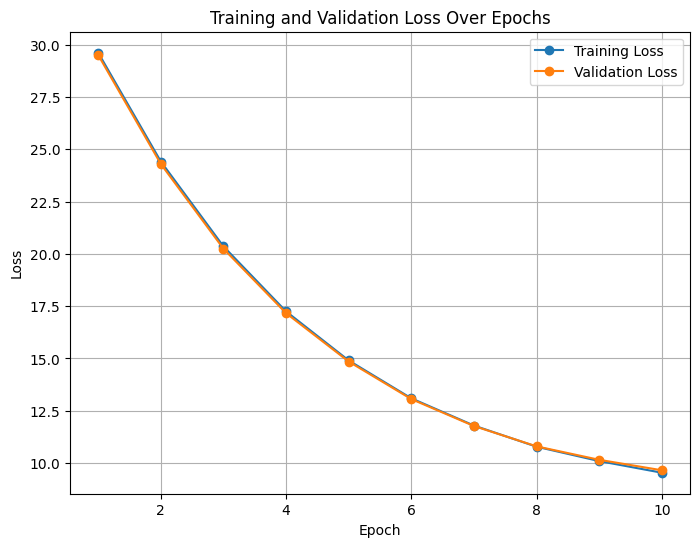

In [71]:
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Define features and targets
X = data.drop(['Nitrogen', 'Phosphorus', 'Potassium'], axis=1)
y = data[['Nitrogen', 'Phosphorus', 'Potassium']]

# Convert columns with string values to numerical using one-hot encoding
X = pd.get_dummies(X)  # Convert categorical columns to numerical

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the XGBoost model with evaluation metrics
xgb_model = XGBRegressor(
    colsample_bytree=1.0,
    learning_rate=0.2,
    max_depth=7,
    n_estimators=10,
    subsample=1.0,
    random_state=42,
    eval_metric="rmse"
)

# Train the model with evaluation sets
eval_set = [(X_train, y_train), (X_val, y_val)]
xgb_model.fit(X_train, y_train, eval_set=eval_set, verbose=True)

# Access evaluation results
results = xgb_model.evals_result()

# Extract training and validation loss
train_loss = results['validation_0']['rmse']
val_loss = results['validation_1']['rmse']
epochs = range(1, len(train_loss) + 1)

# Plot training and validation loss
plt.figure(figsize=(8, 6))
plt.plot(epochs, train_loss, label="Training Loss", marker='o')
plt.plot(epochs, val_loss, label="Validation Loss", marker='o')
plt.title("Training and Validation Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()


In [72]:
# Save the trained XGBoost model

import joblib

joblib.dump(xgb_model, 'D:/DSGP project/DSGP/backend/models/Fertilizer_Prediction.pkl')
print("XGBoost model saved successfully.")



XGBoost model saved successfully.


In [73]:
import joblib

# Load the trained model
model_filename = 'D:/DSGP project/DSGP/backend/models/Fertilizer_Prediction.pkl'
loaded_model = joblib.load(model_filename)


In [74]:
import pandas as pd

# Get user inputs with validation
def get_user_input():
    N = float(input("Enter Nitrogen level (0-100): "))
    P = float(input("Enter Phosphorus level (0-100): "))
    K = float(input("Enter Potassium level (0-100): "))
    pH = float(input("Enter pH value (0-14): "))
    Rainfall = float(input("Enter Rainfall amount (mm): "))
    Temperature = float(input("Enter Temperature (°C): "))
    return N, P, K, pH, Rainfall, Temperature

N, P, K, pH, Rainfall, Temperature = get_user_input()

# Create a DataFrame for the input features
user_input = pd.DataFrame({
    'pH': [pH],
    'Rainfall': [Rainfall],
    'Temperature': [Temperature],
    'Nitrogen': [N],
    'Phosphorus': [P],
    'Potassium': [K],
})

# Add missing columns to align with the training data
missing_cols = list(set(X_train.columns) - set(user_input.columns)) # Convert missing_cols to a list
user_input = pd.concat([user_input, pd.DataFrame(columns=missing_cols)], axis=1).fillna(0)

# Reorder columns to match the training data
user_input = user_input[X_train.columns]

# Predict the NPK ratio using the loaded model
predicted_npk = loaded_model.predict(user_input.values)

# Display the results
print("\nPredicted NPK Ratio:")
print(f"Nitrogen: {predicted_npk[0][0]:.2f}")
print(f"Phosphorus: {predicted_npk[0][1]:.2f}")
print(f"Potassium: {predicted_npk[0][2]:.2f}")



Predicted NPK Ratio:
Nitrogen: 40.08
Phosphorus: 51.11
Potassium: 41.50


C:\Users\dinit\AppData\Local\Temp\ipykernel_2632\2465012056.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  user_input = pd.concat([user_input, pd.DataFrame(columns=missing_cols)], axis=1).fillna(0)
